# SAT para inundaciones  
## Cuenca del río La Estrella, Costa Rica

Este notebook desarrolla un ejercicio práctico de Sistema de Alerta Temprana (SAT) para el curso del CATIE.

El análisis utiliza únicamente dos predictores:

- precipitación diaria y acumulada obtenida de CHIRPS;
- humedad superficial del suelo obtenida de SMAP Nivel 3.

El periodo de estudio comprende del 1 de enero de 2020 al 31 de diciembre de 2025.

Los percentiles P90, P95 y P99 se utilizan como umbrales ilustrativos. Este ejercicio no constituye un SAT operativo y los umbrales no han sido calibrados con registros históricos de inundación, niveles de río o caudales.


In [2]:
# Librerías

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

# Autenticación e inicialización de Earth Engine
try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='coracatie017') # <- cambiar a su proyecto de GEE debe estar registrado en GEE

print("Entorno de Google Earth Engine configurado y autenticado correctamente.")


Entorno de Google Earth Engine configurado y autenticado correctamente.


In [3]:
# Delimitación de la cuenca del río La Estrella

# --- VARIABLES DE CONTROL ---
# Nombre estándar de la base de datos FAO GAUL
PAIS_NOMBRE = 'Costa Rica'

# ID único de la cuenca (HYBAS_ID) proveniente de HydroBASINS Nivel 10
CUENCA_ID = 7100054890
# -----------------------------------------------------------
##TODO inspeccionar la fuente de datos geolibre ?

print(f"Parámetros establecidos: País - {PAIS_NOMBRE}, ID de Cuenca - {CUENCA_ID}")


Parámetros establecidos: País - Costa Rica, ID de Cuenca - 7100054890


## 1. Parámetros del periodo de análisis

La fecha final en Earth Engine se define como 2026-01-01 porque `filterDate()` excluye el límite superior. De esta manera se incluyen todos los días hasta el 31 de diciembre de 2025.


In [4]:
# Periodo común de análisis

fecha_inicio = '2020-01-01'
fecha_fin = '2026-01-01'

print('Periodo analizado: 2020-01-01 a 2025-12-31')


Periodo analizado: 2020-01-01 a 2025-12-31


## 2. Precipitación diaria CHIRPS

Se calcula la precipitación media diaria sobre la cuenca. Posteriormente se obtienen acumulados móviles de 24, 48 y 72 horas.


In [5]:
# Colección CHIRPS diaria

chirps = (
    ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
    .filterDate(fecha_inicio, fecha_fin)
    .select('precipitation')
)

print('Número de imágenes CHIRPS:', chirps.size().getInfo())


Número de imágenes CHIRPS: 2192


In [6]:
# ID de la cuenca del río La Estrella
CUENCA_ID = 7100054890

# HydroBASINS Nivel 10, colección pública oficial de Earth Engine
hydrobasins = ee.FeatureCollection(
    'WWF/HydroSHEDS/v1/Basins/hybas_10'
)

# Seleccionar la cuenca
cuenca_filtrada = hydrobasins.filter(
    ee.Filter.eq('HYBAS_ID', CUENCA_ID)
)

# Comprobar que el ID exista
cantidad = cuenca_filtrada.size().getInfo()

print('Número de polígonos encontrados:', cantidad)

if cantidad == 0:
    raise ValueError(
        f'No se encontró el HYBAS_ID {CUENCA_ID} '
        'en HydroBASINS nivel 10.'
    )

# Obtener la geometría
geometria_cuenca = cuenca_filtrada.geometry()

print('Geometría de la cuenca cargada correctamente.')

Número de polígonos encontrados: 1
Geometría de la cuenca cargada correctamente.


In [7]:
def extraer_lluvia_diaria(image):
    valor = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometria_cuenca,
        scale=5500,
        bestEffort=True,
        maxPixels=1e8,
        tileScale=2
    ).get('precipitation')

    return ee.Feature(
        None,
        {
            'fecha': ee.Date(
                image.get('system:time_start')
            ).format('YYYY-MM-dd'),
            'lluvia_mm': valor
        }
    )


fc_lluvia = (
    ee.FeatureCollection(
        chirps.map(extraer_lluvia_diaria)
    )
    .filter(ee.Filter.notNull(['lluvia_mm']))
)

df_lluvia = geemap.ee_to_df(fc_lluvia)

df_lluvia['fecha'] = pd.to_datetime(
    df_lluvia['fecha'],
    errors='coerce'
)

df_lluvia['lluvia_mm'] = pd.to_numeric(
    df_lluvia['lluvia_mm'],
    errors='coerce'
)

df_lluvia = (
    df_lluvia
    .dropna(subset=['fecha', 'lluvia_mm'])
    .sort_values('fecha')
    .drop_duplicates(subset='fecha')
    .reset_index(drop=True)
)

print(
    'Registros diarios de precipitación:',
    len(df_lluvia)
)

display(df_lluvia.head())

Registros diarios de precipitación: 2192


,fecha,lluvia_mm
0,2020-01-01,0.000000
1,2020-01-02,1.901914
2,2020-01-03,5.983122
3,2020-01-04,0.000000
4,2020-01-05,9.225209


In [8]:
Map = geemap.Map()

Map.centerObject(cuenca_filtrada, 10)

Map.addLayer(
    cuenca_filtrada,
    {
        'color': 'blue',
        'fillColor': '00000000'
    },
    'Cuenca del río La Estrella'
)

Map

Map(center=[9.76191000655522, -82.9685618298471], controls=(WidgetControl(options=['position', 'transparent_bg…

In [9]:
# ============================================================
# EXTRACCIÓN DE PRECIPITACIÓN MEDIA DIARIA SOBRE LA CUENCA
# Fuente: CHIRPS Daily
# Periodo: 2020–2025
# ============================================================

# Periodo de análisis
fecha_inicio = '2020-01-01'
fecha_fin = '2026-01-01'  # Incluye hasta el 31 de diciembre de 2025

# Cargar la colección diaria de precipitación CHIRPS
chirps = (
    ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
    .filterDate(fecha_inicio, fecha_fin)
    .select('precipitation')
)

print(
    'Número de imágenes CHIRPS:',
    chirps.size().getInfo()
)


# Función para calcular la precipitación media diaria
# dentro de la geometría de la cuenca
def extraer_lluvia_diaria(imagen):

    precipitacion_media = imagen.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometria_cuenca,
        scale=5500,
        bestEffort=True,
        maxPixels=1e9,
        tileScale=4
    ).get('precipitation')

    fecha = ee.Date(
        imagen.get('system:time_start')
    ).format('YYYY-MM-dd')

    return ee.Feature(
        None,
        {
            'fecha': fecha,
            'lluvia_mm': precipitacion_media
        }
    )


# Aplicar la función a todas las imágenes de CHIRPS
fc_lluvia = ee.FeatureCollection(
    chirps.map(extraer_lluvia_diaria)
)

# Eliminar registros sin precipitación
fc_lluvia = fc_lluvia.filter(
    ee.Filter.notNull(['lluvia_mm'])
)

print(
    'Registros válidos en Earth Engine:',
    fc_lluvia.size().getInfo()
)


# Convertir la FeatureCollection en un DataFrame de pandas
df_lluvia = geemap.ee_to_df(fc_lluvia)

# Convertir la fecha al formato datetime
df_lluvia['fecha'] = pd.to_datetime(
    df_lluvia['fecha'],
    errors='coerce'
)

# Convertir los valores de precipitación a formato numérico
df_lluvia['lluvia_mm'] = pd.to_numeric(
    df_lluvia['lluvia_mm'],
    errors='coerce'
)

# Limpiar y ordenar la tabla
df_lluvia = (
    df_lluvia
    .dropna(subset=['fecha', 'lluvia_mm'])
    .sort_values('fecha')
    .drop_duplicates(subset=['fecha'])
    .reset_index(drop=True)
)

print(
    'Registros diarios de precipitación:',
    len(df_lluvia)
)

print(
    'Fecha inicial:',
    df_lluvia['fecha'].min()
)

print(
    'Fecha final:',
    df_lluvia['fecha'].max()
)

display(df_lluvia.head())

Número de imágenes CHIRPS: 2192
Registros válidos en Earth Engine: 2192
Registros diarios de precipitación: 2192
Fecha inicial: 2020-01-01 00:00:00
Fecha final: 2025-12-31 00:00:00


,fecha,lluvia_mm
0,2020-01-01,0.000000
1,2020-01-02,1.901914
2,2020-01-03,5.983122
3,2020-01-04,0.000000
4,2020-01-05,9.225209


In [10]:
# Acumulados de precipitación de 24, 48 y 72 horas

df_lluvia['lluvia_24h_mm'] = df_lluvia['lluvia_mm']

df_lluvia['lluvia_48h_mm'] = (
    df_lluvia['lluvia_mm']
    .rolling(window=2, min_periods=2)
    .sum()
)

df_lluvia['lluvia_72h_mm'] = (
    df_lluvia['lluvia_mm']
    .rolling(window=3, min_periods=3)
    .sum()
)

display(df_lluvia.tail())


,fecha,lluvia_mm,lluvia_24h_mm,lluvia_48h_mm,lluvia_72h_mm
2187,2025-12-27,0.0,0.0,0.0,0.0
2188,2025-12-28,0.0,0.0,0.0,0.0
2189,2025-12-29,0.0,0.0,0.0,0.0
2190,2025-12-30,0.0,0.0,0.0,0.0
2191,2025-12-31,0.0,0.0,0.0,0.0


## 3. Humedad superficial del suelo SMAP L3

Para cubrir todo el periodo 2020–2025 se combinan dos versiones consecutivas del producto diario SMAP L3:

- `NASA/SMAP/SPL3SMP_E/005` para 2020 hasta el 3 de diciembre de 2023;
- `NASA/SMAP/SPL3SMP_E/006` desde el 4 de diciembre de 2023 hasta 2025.

Se utiliza la banda `soil_moisture_am`, correspondiente a humedad superficial del suelo durante el paso matutino.


In [11]:
# Colecciones SMAP Nivel 3 para cubrir 2020-2025

smap_l3_v005 = (
    ee.ImageCollection('NASA/SMAP/SPL3SMP_E/005')
    .filterDate(fecha_inicio, '2023-12-04')
    .select('soil_moisture_am')
)

smap_l3_v006 = (
    ee.ImageCollection('NASA/SMAP/SPL3SMP_E/006')
    .filterDate('2023-12-04', fecha_fin)
    .select('soil_moisture_am')
)

smap_l3 = smap_l3_v005.merge(smap_l3_v006).sort(
    'system:time_start'
)

print('Número de imágenes SMAP L3:', smap_l3.size().getInfo())


Número de imágenes SMAP L3: 2140


In [12]:
# Extracción de humedad superficial media para la cuenca

def extraer_humedad_superficial(image):
    valor = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometria_cuenca,
        scale=9000,
        bestEffort=True,
        maxPixels=1e8,
        tileScale=2
    ).get('soil_moisture_am')

    return ee.Feature(
        None,
        {
            'fecha': ee.Date(
                image.get('system:time_start')
            ).format('YYYY-MM-dd'),
            'humedad_superficial': valor
        }
    )

fc_smap = (
    ee.FeatureCollection(
        smap_l3.map(extraer_humedad_superficial)
    )
    .filter(
        ee.Filter.notNull(['humedad_superficial'])
    )
)

df_smap = geemap.ee_to_df(fc_smap)

df_smap['fecha'] = pd.to_datetime(
    df_smap['fecha'],
    errors='coerce'
)

df_smap['humedad_superficial'] = pd.to_numeric(
    df_smap['humedad_superficial'],
    errors='coerce'
)

df_smap = (
    df_smap
    .dropna(subset=['fecha', 'humedad_superficial'])
    .sort_values('fecha')
    .drop_duplicates(subset='fecha')
    .reset_index(drop=True)
)

print('Registros válidos de humedad SMAP L3:', len(df_smap))
display(df_smap.head())


Registros válidos de humedad SMAP L3: 1008


,fecha,humedad_superficial
0,2020-01-01,0.567910
1,2020-01-03,0.411018
2,2020-01-04,0.559697
3,2020-01-06,0.411115
4,2020-01-09,0.560971


In [13]:
# Humedad superficial antecedente de tres observaciones

# SMAP no necesariamente tiene una observación válida todos los días.
# Por ello este indicador corresponde al promedio de las tres
# observaciones previas disponibles, no necesariamente tres días consecutivos.

df_smap['humedad_antecedente_3obs'] = (
    df_smap['humedad_superficial']
    .rolling(window=3, min_periods=1)
    .mean()
    .shift(1)
)

display(df_smap.tail())


,fecha,humedad_superficial,humedad_antecedente_3obs
1003,2025-12-22,0.574114,0.502788
1004,2025-12-24,0.434661,0.504687
1005,2025-12-27,0.568417,0.460101
1006,2025-12-29,0.495982,0.525731
1007,2025-12-30,0.574114,0.499687


## 4. Gráficos mensuales

La precipitación se presenta como acumulado mensual. La humedad superficial se presenta como promedio mensual porque es una proporción volumétrica y no debe sumarse.


,Año,Mes,precipitacion_mensual_mm,Fecha
0,2020,1,434.266552,2020-01-01
1,2020,2,118.665076,2020-02-01
2,2020,3,89.799992,2020-03-01
3,2020,4,114.848134,2020-04-01
4,2020,5,176.254706,2020-05-01


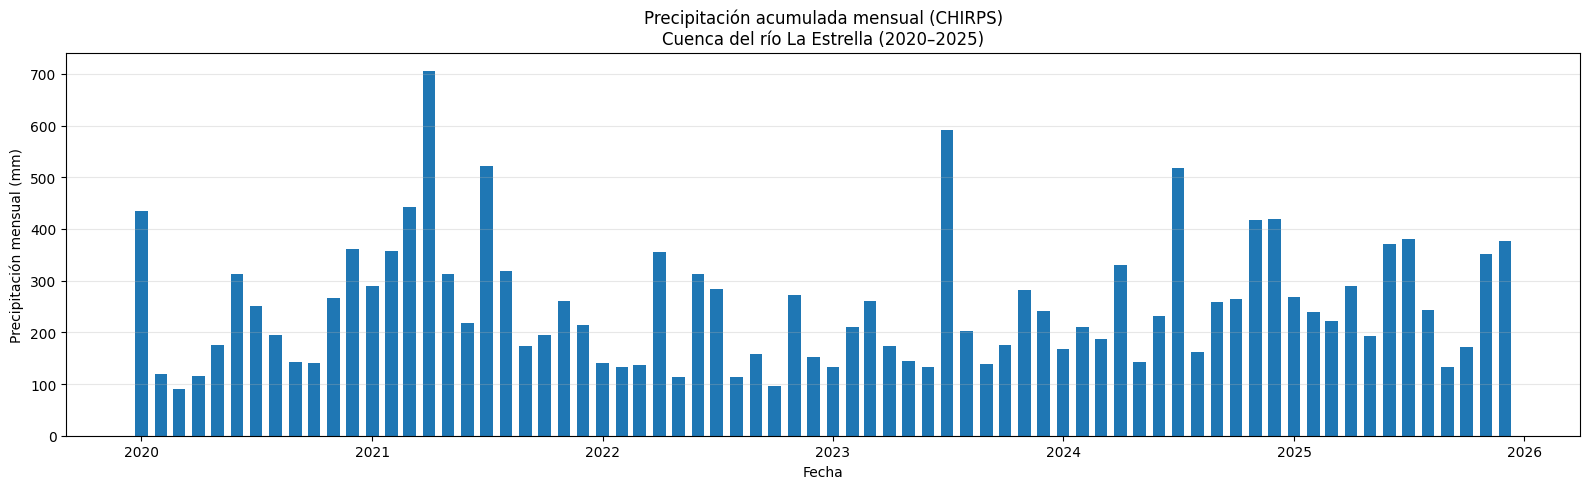

In [14]:
# ============================================================
# PRECIPITACIÓN ACUMULADA MENSUAL
# ============================================================

df_lluvia['Año'] = df_lluvia['fecha'].dt.year
df_lluvia['Mes'] = df_lluvia['fecha'].dt.month

lluvia_mensual = (
    df_lluvia
    .groupby(['Año', 'Mes'], as_index=False)
    .agg(
        precipitacion_mensual_mm=('lluvia_mm', 'sum')
    )
)

# Crear una fecha para graficar
lluvia_mensual['Fecha'] = pd.to_datetime(
    lluvia_mensual[['Año','Mes']]
    .rename(columns={'Año': 'year', 'Mes': 'month'}) # Renombra las columnas a 'year' y 'month'
    .assign(day=1)
)

display(lluvia_mensual.head())

plt.figure(figsize=(16,5))

plt.bar(
    lluvia_mensual['Fecha'],
    lluvia_mensual['precipitacion_mensual_mm'],
    width=20
)

plt.title(
    'Precipitación acumulada mensual (CHIRPS)\n'
    'Cuenca del río La Estrella (2020–2025)'
)

plt.xlabel('Fecha')
plt.ylabel('Precipitación mensual (mm)')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

,Año,Mes,humedad_media,Fecha
0,2020,1,0.517986,2020-01-01
1,2020,2,0.534898,2020-02-01
2,2020,3,0.478824,2020-03-01
3,2020,4,0.432337,2020-04-01
4,2020,5,0.452263,2020-05-01


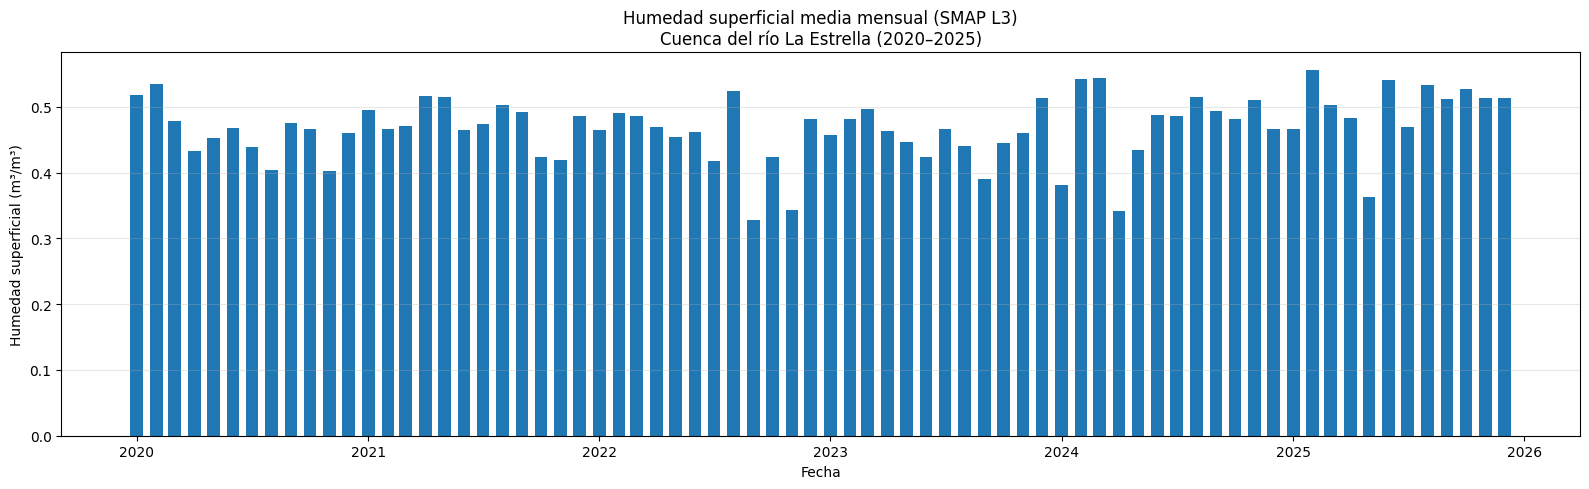

In [15]:
# ============================================================
# HUMEDAD SUPERFICIAL MEDIA MENSUAL
# ============================================================

df_smap['Año'] = df_smap['fecha'].dt.year
df_smap['Mes'] = df_smap['fecha'].dt.month

humedad_mensual = (
    df_smap
    .groupby(['Año','Mes'], as_index=False)
    .agg(
        humedad_media=('humedad_superficial','mean')
    )
)

humedad_mensual['Fecha'] = pd.to_datetime(
    humedad_mensual[['Año','Mes']]
    .rename(columns={'Año': 'year', 'Mes': 'month'}) # Renombra las columnas a 'year' y 'month'
    .assign(day=1)
)

display(humedad_mensual.head())

plt.figure(figsize=(16,5))

plt.bar(
    humedad_mensual['Fecha'],
    humedad_mensual['humedad_media'],
    width=20
)

plt.title(
    'Humedad superficial media mensual (SMAP L3)\n'
    'Cuenca del río La Estrella (2020–2025)'
)

plt.xlabel('Fecha')
plt.ylabel('Humedad superficial (m³/m³)')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Integración de lluvia y humedad

La unión se realiza por fecha. Debido a que SMAP no siempre presenta un valor válido diario, solo se conservan fechas con datos disponibles de ambas fuentes.


In [16]:
# Integración de las dos variables predictoras

columnas_lluvia = [
    'fecha',
    'lluvia_mm',
    'lluvia_24h_mm',
    'lluvia_48h_mm',
    'lluvia_72h_mm'
]

columnas_humedad = [
    'fecha',
    'humedad_superficial',
    'humedad_antecedente_3obs'
]

df_sat = df_lluvia[columnas_lluvia].merge(
    df_smap[columnas_humedad],
    on='fecha',
    how='inner'
)

df_sat = (
    df_sat
    .dropna(
        subset=[
            'lluvia_24h_mm',
            'lluvia_48h_mm',
            'lluvia_72h_mm',
            'humedad_superficial'
        ]
    )
    .sort_values('fecha')
    .reset_index(drop=True)
)

print('Registros integrados CHIRPS-SMAP:', len(df_sat))
display(df_sat.head())


Registros integrados CHIRPS-SMAP: 1007


,fecha,lluvia_mm,lluvia_24h_mm,lluvia_48h_mm,lluvia_72h_mm,humedad_superficial,humedad_antecedente_3obs
0,2020-01-03,5.983122,5.983122,7.885036,7.885036,0.411018,0.567910
1,2020-01-04,0.000000,0.000000,5.983122,7.885036,0.559697,0.489464
2,2020-01-06,0.000000,0.000000,9.225209,9.225209,0.411115,0.512875
3,2020-01-09,2.637118,2.637118,6.312114,6.312114,0.560971,0.460610
4,2020-01-11,0.000000,0.000000,1.680876,4.317995,0.510582,0.510594


## 6. Percentiles P90, P95 y P98

---



Los percentiles se calculan utilizando todas las observaciones disponibles entre 2020 y 2025, no los promedios anuales. Esto permite representar eventos relativamente extremos dentro de la serie diaria.


In [17]:
# Cálculo de P90, P95 y P98

variables_percentiles = {
    'Precipitación 24 h (mm)': 'lluvia_24h_mm',
    'Precipitación 48 h (mm)': 'lluvia_48h_mm',
    'Precipitación 72 h (mm)': 'lluvia_72h_mm',
    'Humedad superficial (m³/m³)': 'humedad_superficial',
    'Humedad antecedente 3 obs. (m³/m³)': 'humedad_antecedente_3obs'
}

filas = []

for nombre, columna in variables_percentiles.items():
    serie = pd.to_numeric(
        df_sat[columna],
        errors='coerce'
    ).dropna()

    filas.append({
        'Variable': nombre,
        'P90': serie.quantile(0.90),
        'P95': serie.quantile(0.95),
        'P98': serie.quantile(0.98),
        'Número de observaciones': len(serie)
    })

tabla_percentiles = pd.DataFrame(filas)

display(
    tabla_percentiles.style.format({
        'P90': '{:.3f}',
        'P95': '{:.3f}',
        'P98': '{:.3f}'
    })
)


,Variable,P90,P95,P98,Número de observaciones
0,Precipitación 24 h (mm),21.416,36.478,56.029,1007
1,Precipitación 48 h (mm),45.171,64.796,98.042,1007
2,Precipitación 72 h (mm),59.436,87.728,135.080,1007
3,Humedad superficial (m³/m³),0.568,0.568,0.573,1007
4,Humedad antecedente 3 obs. (m³/m³),0.549,0.562,0.568,1007


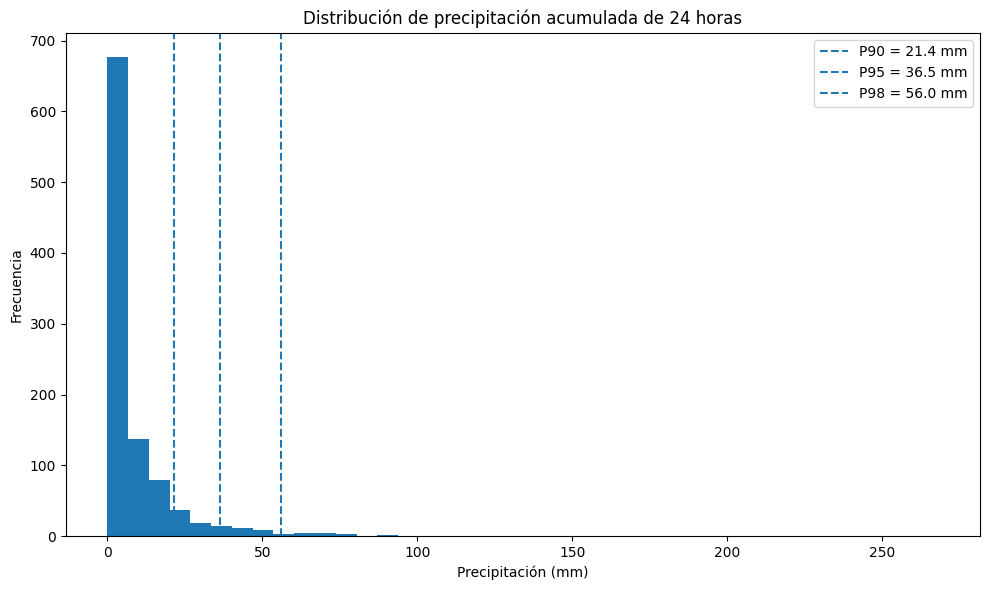

In [18]:
# Histogramas con los percentiles de precipitación y humedad

# Precipitación acumulada de 24 horas
p_lluvia = df_sat['lluvia_24h_mm'].quantile(
    [0.90, 0.95, 0.98]
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df_sat['lluvia_24h_mm'].dropna(),
    bins=40
)

ax.axvline(
    p_lluvia.loc[0.90],
    linestyle='--',
    label=f"P90 = {p_lluvia.loc[0.90]:.1f} mm"
)
ax.axvline(
    p_lluvia.loc[0.95],
    linestyle='--',
    label=f"P95 = {p_lluvia.loc[0.95]:.1f} mm"
)
ax.axvline(
    p_lluvia.loc[0.98],
    linestyle='--',
    label=f"P98 = {p_lluvia.loc[0.98]:.1f} mm"
)

ax.set_title('Distribución de precipitación acumulada de 24 horas')
ax.set_xlabel('Precipitación (mm)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.show()


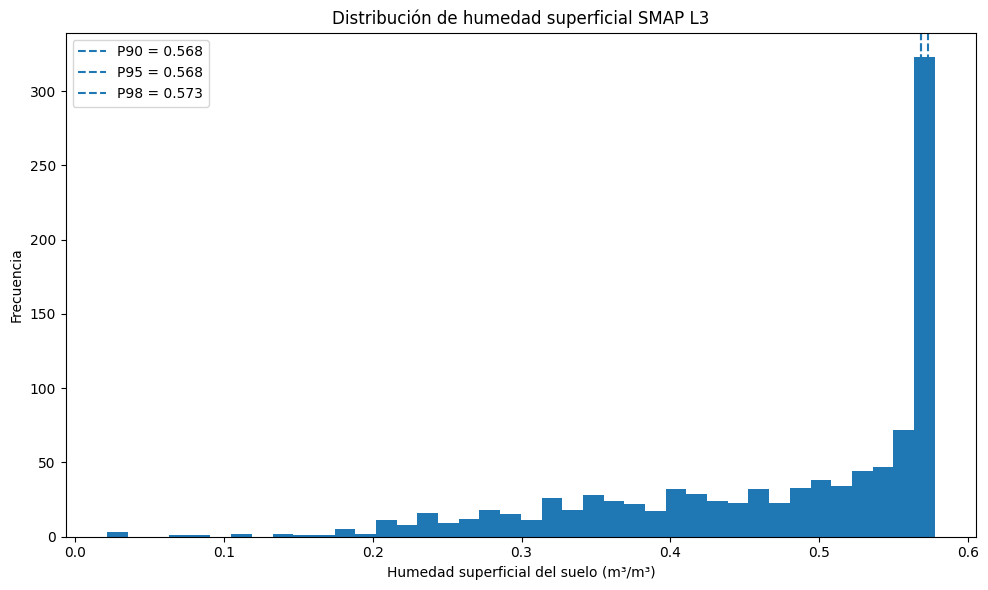

In [19]:
# Humedad superficial SMAP L3

p_humedad = df_sat['humedad_superficial'].quantile(
    [0.90, 0.95, 0.98]
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df_sat['humedad_superficial'].dropna(),
    bins=40
)

ax.axvline(
    p_humedad.loc[0.90],
    linestyle='--',
    label=f"P90 = {p_humedad.loc[0.90]:.3f}"
)
ax.axvline(
    p_humedad.loc[0.95],
    linestyle='--',
    label=f"P95 = {p_humedad.loc[0.95]:.3f}"
)
ax.axvline(
    p_humedad.loc[0.98],
    linestyle='--',
    label=f"P98 = {p_humedad.loc[0.98]:.3f}"
)

ax.set_title('Distribución de humedad superficial SMAP L3')
ax.set_xlabel('Humedad superficial del suelo (m³/m³)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.show()


## 7. Clasificación de niveles de alerta

Para este ejercicio, el nivel de alerta se determina usando precipitación acumulada de 24 horas y humedad superficial del suelo.

La regla es deliberadamente sencilla:

- **Verde:** ninguna variable alcanza P90.
- **Amarillo:** ambas variables alcanzan P90.
- **Naranja:** ambas variables alcanzan P95.
- **Rojo:** ambas variables alcanzan P98.

Esta combinación exige que la lluvia y la humedad sean simultáneamente elevadas. Es una regla ilustrativa y no una validación operacional del riesgo de inundación.


In [21]:
# Umbrales principales para el SAT académico

umbrales = {
    'lluvia_p90': df_sat['lluvia_24h_mm'].quantile(0.90),
    'lluvia_p95': df_sat['lluvia_24h_mm'].quantile(0.95),
    'lluvia_p98': df_sat['lluvia_24h_mm'].quantile(0.98),
    'humedad_p90': df_sat['humedad_superficial'].quantile(0.90),
    'humedad_p95': df_sat['humedad_superficial'].quantile(0.95),
    'humedad_p98': df_sat['humedad_superficial'].quantile(0.98)
}

def clasificar_alerta(fila):
    lluvia = fila['lluvia_24h_mm']
    humedad = fila['humedad_superficial']

    if (
        lluvia >= umbrales['lluvia_p98']
        and humedad >= umbrales['humedad_p98']
    ):
        return 'Rojo'

    if (
        lluvia >= umbrales['lluvia_p95']
        and humedad >= umbrales['humedad_p95']
    ):
        return 'Naranja'

    if (
        lluvia >= umbrales['lluvia_p90']
        and humedad >= umbrales['humedad_p90']
    ):
        return 'Amarillo'

    return 'Verde'

df_sat['nivel_alerta'] = df_sat.apply(
    clasificar_alerta,
    axis=1
)

resumen_alertas = (
    df_sat['nivel_alerta']
    .value_counts()
    .reindex(
        ['Verde', 'Amarillo', 'Naranja', 'Rojo'],
        fill_value=0
    )
    .rename_axis('Nivel')
    .reset_index(name='Número de días')
)

display(resumen_alertas)


,Nivel,Número de días
0,Verde,984
1,Amarillo,16
2,Naranja,5
3,Rojo,2


In [22]:
# Tabla descriptiva de niveles y umbrales

tabla_alertas = pd.DataFrame({
    'Nivel': ['Verde', 'Amarillo', 'Naranja', 'Rojo'],
    'Precipitación 24 h': [
        f"< {umbrales['lluvia_p90']:.2f} mm",
        f"≥ {umbrales['lluvia_p90']:.2f} mm",
        f"≥ {umbrales['lluvia_p95']:.2f} mm",
        f"≥ {umbrales['lluvia_p98']:.2f} mm"
    ],
    'Humedad superficial': [
        f"< {umbrales['humedad_p90']:.3f} m³/m³",
        f"≥ {umbrales['humedad_p90']:.3f} m³/m³",
        f"≥ {umbrales['humedad_p95']:.3f} m³/m³",
        f"≥ {umbrales['humedad_p98']:.3f} m³/m³"
    ],
    'Interpretación académica': [
        'Condiciones ordinarias',
        'Condiciones elevadas',
        'Condiciones muy elevadas',
        'Condiciones extremas'
    ]
})

display(tabla_alertas)


,Nivel,Precipitación 24 h,Humedad superficial,Interpretación académica
0,Verde,< 21.42 mm,< 0.568 m³/m³,Condiciones ordinarias
1,Amarillo,≥ 21.42 mm,≥ 0.568 m³/m³,Condiciones elevadas
2,Naranja,≥ 36.48 mm,≥ 0.568 m³/m³,Condiciones muy elevadas
3,Rojo,≥ 56.03 mm,≥ 0.573 m³/m³,Condiciones extremas


In [23]:
# Eventos que alcanzaron algún nivel de alerta

eventos_alerta = df_sat.loc[
    df_sat['nivel_alerta'] != 'Verde',
    [
        'fecha',
        'lluvia_24h_mm',
        'lluvia_48h_mm',
        'lluvia_72h_mm',
        'humedad_superficial',
        'nivel_alerta'
    ]
].copy()

eventos_alerta = eventos_alerta.sort_values(
    ['nivel_alerta', 'fecha']
)

print('Número de eventos no verdes:', len(eventos_alerta))
display(eventos_alerta.head(20))


Número de eventos no verdes: 23


,fecha,lluvia_24h_mm,lluvia_48h_mm,lluvia_72h_mm,humedad_superficial,nivel_alerta
572,2023-05-31,32.163751,42.123524,42.620221,0.568417,Amarillo
693,2024-02-21,31.037904,61.360923,67.325924,0.568417,Amarillo
747,2024-06-15,29.521676,46.483264,56.197531,0.568417,Amarillo
754,2024-07-01,33.884226,33.884226,45.102008,0.568417,Amarillo
760,2024-07-12,22.023939,42.084411,45.441121,0.574114,Amarillo
789,2024-09-19,23.832657,23.832657,47.665314,0.568417,Amarillo
815,2024-11-09,34.504443,72.123935,94.408820,0.568417,Amarillo
818,2024-11-17,21.825036,25.198015,28.249531,0.568417,Amarillo
845,2025-01-25,21.722929,38.887307,57.010397,0.568417,Amarillo
880,2025-04-07,35.622898,35.622898,36.586164,0.568417,Amarillo


## 8. Exportación de resultados


In [24]:
# Exportación a archivos CSV

df_sat.to_csv(
    'serie_sat_chirps_smap_l3_2020_2025.csv',
    index=False
)

tabla_percentiles.to_csv(
    'percentiles_sat_p90_p95_p99.csv',
    index=False
)

tabla_alertas.to_csv(
    'umbrales_sat.csv',
    index=False
)

eventos_alerta.to_csv(
    'eventos_alerta_academica.csv',
    index=False
)

print('Archivos generados:')
print('- serie_sat_chirps_smap_l3_2020_2025.csv')
print('- percentiles_sat_p90_p95_p99.csv')
print('- umbrales_sat.csv')
print('- eventos_alerta_academica.csv')


Archivos generados:
- serie_sat_chirps_smap_l3_2020_2025.csv
- percentiles_sat_p90_p95_p99.csv
- umbrales_sat.csv
- eventos_alerta_academica.csv


## Limitaciones

- Los valores de CHIRPS y SMAP representan promedios espaciales para la cuenca.
- La resolución de ambos productos limita la representación de variaciones locales.
- SMAP puede presentar días sin observaciones válidas.
- Los percentiles describen extremos estadísticos, pero no prueban que exista una inundación.
- Los niveles propuestos no han sido calibrados con caudales, niveles del río, sensores locales ni inventarios de inundaciones.



In [26]:
#PRUEBAS

df_sat['humedad_superficial'].describe()

,humedad_superficial
count,1007.000000
mean,0.469145
std,0.113736
min,0.021339
25%,0.395907
50%,0.514283
75%,0.567910
max,0.577729


In [27]:
df_sat['humedad_superficial'].nunique()

711

In [28]:
for p in [0.95, 0.96, 0.97, 0.975, 0.98, 0.985, 0.99]:
    valor = df_sat['lluvia_24h_mm'].quantile(p)
    print(f"P{p*100:.1f}: {valor:.2f} mm")

P95.0: 36.48 mm
P96.0: 41.10 mm
P97.0: 48.15 mm
P97.5: 51.19 mm
P98.0: 56.03 mm
P98.5: 63.88 mm
P99.0: 75.95 mm


In [29]:
#Prueba para definir los umbrales de humedad
df_sat['humedad_superficial'].describe()

,humedad_superficial
count,1007.000000
mean,0.469145
std,0.113736
min,0.021339
25%,0.395907
50%,0.514283
75%,0.567910
max,0.577729


In [30]:
df_sat['humedad_superficial'].quantile([0.90,0.95,0.97,0.98,0.99])

,humedad_superficial
0.90,0.568417
0.95,0.568417
0.97,0.568417
0.98,0.573217
0.99,0.574114


In [31]:
df_sat['lluvia_24h_mm'].quantile([0.96, 0.97, 0.975, 0.98, 0.985, 0.99])

,lluvia_24h_mm
0.960,41.095373
0.970,48.154585
0.975,51.190634
0.980,56.028948
0.985,63.883705
0.990,75.948707


In [32]:
df_lluvia['año'] = df_lluvia['fecha'].dt.year
df_lluvia['mes'] = df_lluvia['fecha'].dt.month

lluvia_mensual = (
    df_lluvia.groupby(['año', 'mes'])
    .agg(lluvia_total_mm=('lluvia_mm', 'sum'))
    .reset_index()
    .set_index(['año', 'mes'])
)

lluvia_mensual.loc[(2021, 7)]

,2021
,7
lluvia_total_mm,521.368716


<Axes: >

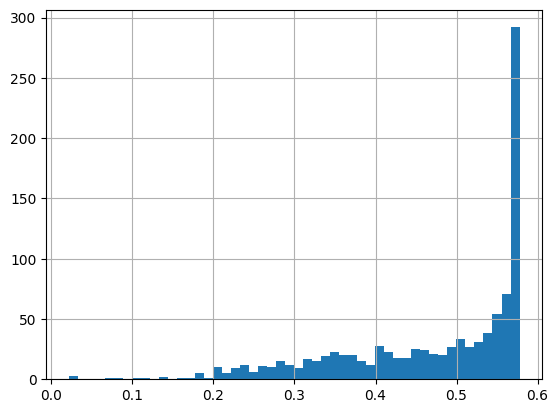

In [33]:
df_sat['humedad_superficial'].hist(bins=50)

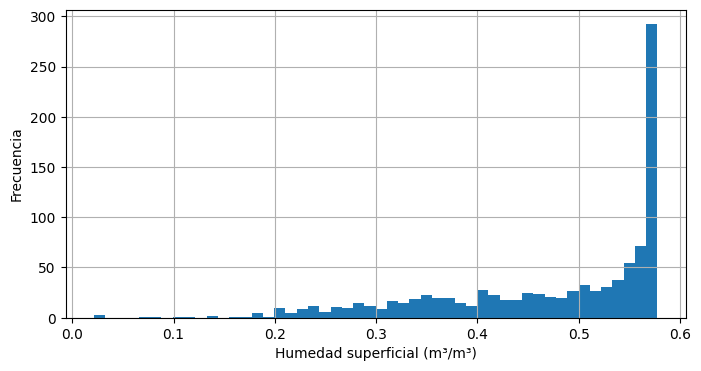

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df_sat['humedad_superficial'], bins=50)
plt.xlabel('Humedad superficial (m³/m³)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

In [35]:
(df_sat['lluvia_24h_mm'] >= 63.88) & (df_sat['humedad_superficial'] >= 0.573217)

,0
0,False
1,False
2,False
3,False
4,False
...,...
1002,False
1003,False
1004,False
1005,False


In [36]:
cond = (
    (df_sat['lluvia_24h_mm'] >= 63.883705) &
    (df_sat['humedad_superficial'] >= 0.573217)
)

df_sat[cond]

,fecha,lluvia_mm,lluvia_24h_mm,lluvia_48h_mm,lluvia_72h_mm,humedad_superficial,humedad_antecedente_3obs,nivel_alerta
283,2021-08-02,63.982500,63.982500,123.323350,123.323350,0.574114,0.531904,Rojo
874,2025-03-25,132.095967,132.095967,132.095967,132.095967,0.573217,0.468690,Rojo


In [37]:
# ============================================================
# EXPORTAR BASE DE DATOS FINAL DEL SAT A CSV
# ============================================================

# Seleccionar las variables que utilizará la aplicación
columnas_sat = [
    'fecha',
    'lluvia_mm',
    'lluvia_24h_mm',
    'lluvia_48h_mm',
    'lluvia_72h_mm',
    'humedad_superficial',
    'humedad_antecedente_3obs',
    'nivel_alerta'
]

# Crear una copia de la base final
df_exportar = df_sat[columnas_sat].copy()

# Ordenar cronológicamente
df_exportar = (
    df_exportar
    .sort_values('fecha')
    .reset_index(drop=True)
)

# Guardar como CSV
nombre_archivo = 'SAT_Rio_La_Estrella_2020_2025.csv'

df_exportar.to_csv(
    nombre_archivo,
    index=False,
    encoding='utf-8-sig'
)

print('CSV generado correctamente:')
print(nombre_archivo)

print('\nNúmero de registros:', len(df_exportar))
print('Fecha inicial:', df_exportar['fecha'].min())
print('Fecha final:', df_exportar['fecha'].max())

display(df_exportar.head())

CSV generado correctamente:
SAT_Rio_La_Estrella_2020_2025.csv

Número de registros: 1007
Fecha inicial: 2020-01-03 00:00:00
Fecha final: 2025-12-30 00:00:00


,fecha,lluvia_mm,lluvia_24h_mm,lluvia_48h_mm,lluvia_72h_mm,humedad_superficial,humedad_antecedente_3obs,nivel_alerta
0,2020-01-03,5.983122,5.983122,7.885036,7.885036,0.411018,0.567910,Verde
1,2020-01-04,0.000000,0.000000,5.983122,7.885036,0.559697,0.489464,Verde
2,2020-01-06,0.000000,0.000000,9.225209,9.225209,0.411115,0.512875,Verde
3,2020-01-09,2.637118,2.637118,6.312114,6.312114,0.560971,0.460610,Verde
4,2020-01-11,0.000000,0.000000,1.680876,4.317995,0.510582,0.510594,Verde


In [38]:
from google.colab import files

files.download(
    'SAT_Rio_La_Estrella_2020_2025.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
%%writefile app.py

# ============================================================
# SISTEMA DE ALERTA TEMPRANA - RÍO LA ESTRELLA
# Aplicación académica CATIE
# ============================================================

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

st.set_page_config(
    page_title="SAT Río La Estrella",
    page_icon="🌧️",
    layout="wide"
)


# ============================================================
# CARGAR DATOS
# ============================================================

@st.cache_data
def cargar_datos():

    df = pd.read_csv(
        "SAT_Rio_La_Estrella_2020_2025.csv"
    )

    df["fecha"] = pd.to_datetime(
        df["fecha"],
        errors="coerce"
    )

    # Convertir variables numéricas
    columnas_numericas = [
        "lluvia_mm",
        "lluvia_24h_mm",
        "lluvia_48h_mm",
        "lluvia_72h_mm",
        "humedad_superficial",
        "humedad_antecedente_3obs"
    ]

    for columna in columnas_numericas:

        if columna in df.columns:

            df[columna] = pd.to_numeric(
                df[columna],
                errors="coerce"
            )

    df = (
        df
        .dropna(
            subset=[
                "fecha",
                "lluvia_24h_mm",
                "humedad_superficial"
            ]
        )
        .sort_values("fecha")
        .reset_index(drop=True)
    )

    return df


df = cargar_datos()


# ============================================================
# CALCULAR UMBRALES
# ============================================================

P90_LLUVIA = df[
    "lluvia_24h_mm"
].quantile(0.90)

P95_LLUVIA = df[
    "lluvia_24h_mm"
].quantile(0.95)

P98_LLUVIA = df[
    "lluvia_24h_mm"
].quantile(0.98)

P98_HUMEDAD = df[
    "humedad_superficial"
].quantile(0.98)


# ============================================================
# FUNCIÓN DEL SAT
# ============================================================

def clasificar_alerta(lluvia, humedad):

    # ALERTA ROJA
    if (
        lluvia >= P98_LLUVIA
        and humedad >= P98_HUMEDAD
    ):
        return "Rojo"

    # ALERTA NARANJA
    elif (
        lluvia >= P95_LLUVIA
        and humedad >= P98_HUMEDAD
    ):
        return "Naranja"

    # ALERTA AMARILLA
    elif (
        lluvia >= P90_LLUVIA
        and humedad >= P98_HUMEDAD
    ):
        return "Amarillo"

    # CONDICIONES NORMALES
    else:
        return "Verde"


# Recalcular alertas directamente en la aplicación

df["alerta_app"] = df.apply(
    lambda fila: clasificar_alerta(
        fila["lluvia_24h_mm"],
        fila["humedad_superficial"]
    ),
    axis=1
)


# ============================================================
# ENCABEZADO
# ============================================================

st.title(
    "🌧️ Sistema de Alerta Temprana"
)

st.markdown(
    "### Cuenca del río La Estrella, Costa Rica"
)

st.caption(
    "Ejercicio académico desarrollado para el curso del CATIE"
)

st.info(
    """
    Este Sistema de Alerta Temprana constituye un ejercicio
    académico demostrativo.

    Los niveles de alerta no representan alertas oficiales
    ni han sido calibrados con niveles del río, caudales,
    daños históricos o estaciones hidrometeorológicas.
    """
)


# ============================================================
# BARRA LATERAL
# ============================================================

st.sidebar.header(
    "⚙️ Configuración"
)

st.sidebar.markdown(
    """
    **Periodo histórico**

    2020–2025

    **Predictores**

    🌧️ Precipitación CHIRPS

    💧 Humedad superficial SMAP L3
    """
)


# ============================================================
# SELECTOR DE FECHA
# ============================================================

fecha_seleccionada = st.sidebar.date_input(
    "Seleccione una fecha",
    value=df["fecha"].max().date(),
    min_value=df["fecha"].min().date(),
    max_value=df["fecha"].max().date()
)


registro = df[
    df["fecha"].dt.date
    == fecha_seleccionada
]


# ============================================================
# CREAR PESTAÑAS
# ============================================================

tab_estado, tab_historial, tab_umbrales, tab_metodologia = st.tabs(
    [
        "🚨 Estado del SAT",
        "📊 Historial",
        "🎯 Umbrales",
        "ℹ️ Metodología"
    ]
)


# ============================================================
# TAB 1 — ESTADO DEL SAT
# ============================================================

with tab_estado:

    st.header(
        "Estado del SAT"
    )

    if registro.empty:

        st.warning(
            "No existen datos disponibles para la fecha seleccionada."
        )

    else:

        fila = registro.iloc[0]

        lluvia_24 = fila[
            "lluvia_24h_mm"
        ]

        humedad = fila[
            "humedad_superficial"
        ]

        alerta = fila[
            "alerta_app"
        ]


        # ====================================================
        # PANEL PRINCIPAL DE ALERTA
        # ====================================================

        if alerta == "Rojo":

            st.error(
                """
                ## 🔴 ALERTA ROJA

                Se identifican condiciones extremas de
                precipitación y elevada humedad superficial
                del suelo.
                """
            )


        elif alerta == "Naranja":

            st.warning(
                """
                ## 🟠 ALERTA NARANJA

                Se identifican condiciones muy elevadas
                de precipitación y humedad del suelo.
                """
            )


        elif alerta == "Amarillo":

            st.warning(
                """
                ## 🟡 ALERTA AMARILLA

                Se identifican condiciones elevadas que
                requieren seguimiento.
                """
            )


        else:

            st.success(
                """
                ## 🟢 CONDICIONES NORMALES

                No se identifican condiciones extremas según
                los umbrales estadísticos utilizados por
                este SAT académico.
                """
            )


        # ====================================================
        # MÉTRICAS PRINCIPALES
        # ====================================================

        col1, col2, col3, col4 = st.columns(4)


        col1.metric(
            "🌧️ Precipitación 24 h",
            f"{fila['lluvia_24h_mm']:.1f} mm"
        )


        if "lluvia_48h_mm" in df.columns:

            col2.metric(
                "🌧️ Precipitación 48 h",
                f"{fila['lluvia_48h_mm']:.1f} mm"
            )

        else:

            col2.metric(
                "🌧️ Precipitación 48 h",
                "Sin dato"
            )


        if "lluvia_72h_mm" in df.columns:

            col3.metric(
                "🌧️ Precipitación 72 h",
                f"{fila['lluvia_72h_mm']:.1f} mm"
            )

        else:

            col3.metric(
                "🌧️ Precipitación 72 h",
                "Sin dato"
            )


        col4.metric(
            "💧 Humedad superficial",
            f"{fila['humedad_superficial']:.3f} m³/m³"
        )


        st.divider()


        # ====================================================
        # EXPLICACIÓN DE LA ALERTA
        # ====================================================

        st.subheader(
            "¿Por qué se generó esta condición?"
        )


        col1, col2 = st.columns(2)


        with col1:

            st.markdown(
                "#### 🌧️ Precipitación"
            )

            st.write(
                f"""
                **Valor observado:** {lluvia_24:.1f} mm

                **P90:** {P90_LLUVIA:.1f} mm

                **P95:** {P95_LLUVIA:.1f} mm

                **P98:** {P98_LLUVIA:.1f} mm
                """
            )


        with col2:

            st.markdown(
                "#### 💧 Humedad del suelo"
            )

            st.write(
                f"""
                **Valor observado:** {humedad:.3f} m³/m³

                **P98:** {P98_HUMEDAD:.3f} m³/m³
                """
            )


        # ====================================================
        # INTERPRETACIÓN AUTOMÁTICA
        # ====================================================

        st.subheader(
            "Interpretación"
        )


        if alerta == "Rojo":

            st.write(
                """
                La precipitación acumulada en 24 horas
                alcanzó o superó el percentil P98 y la
                humedad superficial del suelo también
                alcanzó o superó su percentil P98.

                La coincidencia entre lluvia extrema y
                condiciones de alta humedad determina la
                clasificación como **Alerta Roja**.
                """
            )


        elif alerta == "Naranja":

            st.write(
                """
                La precipitación acumulada en 24 horas
                alcanzó o superó el percentil P95 y la
                humedad superficial del suelo alcanzó el
                umbral de alta humedad.

                Estas condiciones corresponden a una
                **Alerta Naranja**.
                """
            )


        elif alerta == "Amarillo":

            st.write(
                """
                La precipitación acumulada en 24 horas
                alcanzó o superó el percentil P90 y el
                suelo presenta condiciones elevadas de
                humedad.

                Estas condiciones corresponden a una
                **Alerta Amarilla**.
                """
            )


        else:

            st.write(
                """
                La combinación de precipitación y humedad
                del suelo no supera simultáneamente los
                umbrales definidos para los niveles de
                alerta.

                El sistema clasifica la fecha seleccionada
                como **condición normal**.
                """
            )


# ============================================================
# PREPARAR DATOS MENSUALES
# ============================================================

df["Año"] = df[
    "fecha"
].dt.year

df["Mes"] = df[
    "fecha"
].dt.month


mensual = (
    df
    .groupby(
        ["Año", "Mes"],
        as_index=False
    )
    .agg(
        precipitacion_mensual=(
            "lluvia_mm",
            "sum"
        ),

        humedad_media=(
            "humedad_superficial",
            "mean"
        )
    )
)


mensual["Fecha"] = pd.to_datetime(
    dict(
        year=mensual["Año"],
        month=mensual["Mes"],
        day=1
    )
)


# ============================================================
# TAB 2 — HISTORIAL
# ============================================================

with tab_historial:

    st.header(
        "Historial hidrometeorológico"
    )


    # ========================================================
    # FILTRO POR AÑO
    # ========================================================

    años = sorted(
        df["fecha"].dt.year.unique()
    )


    años_seleccionados = st.multiselect(
        "Seleccione los años que desea visualizar",
        options=años,
        default=años
    )


    mensual_filtrado = mensual[
        mensual["Año"].isin(
            años_seleccionados
        )
    ]


    # ========================================================
    # GRÁFICOS EN DOS COLUMNAS
    # ========================================================

    col1, col2 = st.columns(2)


    # --------------------------------------------------------
    # PRECIPITACIÓN MENSUAL
    # --------------------------------------------------------

    with col1:

        st.subheader(
            "🌧️ Precipitación mensual"
        )

        fig, ax = plt.subplots(
            figsize=(9, 5)
        )


        ax.bar(
            mensual_filtrado[
                "Fecha"
            ],

            mensual_filtrado[
                "precipitacion_mensual"
            ],

            width=20
        )


        ax.set_title(
            "Precipitación acumulada mensual CHIRPS"
        )

        ax.set_ylabel(
            "Precipitación (mm)"
        )

        ax.set_xlabel(
            "Fecha"
        )

        ax.xaxis.set_major_locator(
            mdates.YearLocator()
        )

        ax.xaxis.set_major_formatter(
            mdates.DateFormatter("%Y")
        )

        ax.grid(
            axis="y",
            alpha=0.3
        )

        plt.xticks(
            rotation=45
        )

        plt.tight_layout()

        st.pyplot(fig)


    # --------------------------------------------------------
    # HUMEDAD MENSUAL
    # --------------------------------------------------------

    with col2:

        st.subheader(
            "💧 Humedad superficial"
        )

        fig, ax = plt.subplots(
            figsize=(9, 5)
        )


        ax.bar(
            mensual_filtrado[
                "Fecha"
            ],

            mensual_filtrado[
                "humedad_media"
            ],

            width=20
        )


        ax.set_title(
            "Humedad superficial media mensual SMAP L3"
        )

        ax.set_ylabel(
            "Humedad superficial (m³/m³)"
        )

        ax.set_xlabel(
            "Fecha"
        )

        ax.xaxis.set_major_locator(
            mdates.YearLocator()
        )

        ax.xaxis.set_major_formatter(
            mdates.DateFormatter("%Y")
        )

        ax.grid(
            axis="y",
            alpha=0.3
        )

        plt.xticks(
            rotation=45
        )

        plt.tight_layout()

        st.pyplot(fig)


    st.divider()


    # ========================================================
    # EVENTOS HISTÓRICOS DE ALERTA
    # ========================================================

    st.subheader(
        "🚨 Eventos históricos de alerta"
    )


    eventos = df[
        df["alerta_app"]
        != "Verde"
    ][
        [
            "fecha",
            "lluvia_24h_mm",
            "lluvia_48h_mm",
            "lluvia_72h_mm",
            "humedad_superficial",
            "alerta_app"
        ]
    ].copy()


    eventos = eventos.rename(
        columns={
            "fecha": "Fecha",
            "lluvia_24h_mm": "Lluvia 24 h (mm)",
            "lluvia_48h_mm": "Lluvia 48 h (mm)",
            "lluvia_72h_mm": "Lluvia 72 h (mm)",
            "humedad_superficial": "Humedad (m³/m³)",
            "alerta_app": "Nivel de alerta"
        }
    )


    st.dataframe(
        eventos,
        use_container_width=True,
        hide_index=True
    )


# ============================================================
# TAB 3 — UMBRALES
# ============================================================

with tab_umbrales:

    st.header(
        "Umbrales estadísticos del SAT"
    )


    # ========================================================
    # MÉTRICAS
    # ========================================================

    col1, col2, col3, col4 = st.columns(4)


    col1.metric(
        "🟡 P90 lluvia",
        f"{P90_LLUVIA:.1f} mm"
    )


    col2.metric(
        "🟠 P95 lluvia",
        f"{P95_LLUVIA:.1f} mm"
    )


    col3.metric(
        "🔴 P98 lluvia",
        f"{P98_LLUVIA:.1f} mm"
    )


    col4.metric(
        "💧 P98 humedad",
        f"{P98_HUMEDAD:.3f} m³/m³"
    )


    st.divider()


    # ========================================================
    # GRÁFICOS DE DISTRIBUCIÓN
    # ========================================================

    col1, col2 = st.columns(2)


    # --------------------------------------------------------
    # DISTRIBUCIÓN PRECIPITACIÓN
    # --------------------------------------------------------

    with col1:

        st.subheader(
            "Distribución de precipitación"
        )


        fig, ax = plt.subplots(
            figsize=(8, 5)
        )


        ax.hist(
            df[
                "lluvia_24h_mm"
            ].dropna(),

            bins=40
        )


        ax.axvline(
            P90_LLUVIA,
            linestyle="--",
            label=f"P90 = {P90_LLUVIA:.1f} mm"
        )


        ax.axvline(
            P95_LLUVIA,
            linestyle="--",
            label=f"P95 = {P95_LLUVIA:.1f} mm"
        )


        ax.axvline(
            P98_LLUVIA,
            linestyle="--",
            label=f"P98 = {P98_LLUVIA:.1f} mm"
        )


        ax.set_xlabel(
            "Precipitación acumulada 24 h (mm)"
        )


        ax.set_ylabel(
            "Frecuencia"
        )


        ax.legend()


        ax.grid(
            axis="y",
            alpha=0.2
        )


        plt.tight_layout()


        st.pyplot(fig)


    # --------------------------------------------------------
    # DISTRIBUCIÓN HUMEDAD
    # --------------------------------------------------------

    with col2:

        st.subheader(
            "Distribución de humedad"
        )


        fig, ax = plt.subplots(
            figsize=(8, 5)
        )


        ax.hist(
            df[
                "humedad_superficial"
            ].dropna(),

            bins=40
        )


        ax.axvline(
            P98_HUMEDAD,
            linestyle="--",
            label=(
                f"P98 = "
                f"{P98_HUMEDAD:.3f} m³/m³"
            )
        )


        ax.set_xlabel(
            "Humedad superficial (m³/m³)"
        )


        ax.set_ylabel(
            "Frecuencia"
        )


        ax.legend()


        ax.grid(
            axis="y",
            alpha=0.2
        )


        plt.tight_layout()


        st.pyplot(fig)


    # ========================================================
    # TABLA DE REGLAS
    # ========================================================

    st.subheader(
        "Reglas de clasificación"
    )


    tabla_reglas = pd.DataFrame(
        {
            "Nivel": [
                "🟢 Verde",
                "🟡 Amarillo",
                "🟠 Naranja",
                "🔴 Rojo"
            ],

            "Precipitación 24 h": [
                f"< {P90_LLUVIA:.1f} mm",
                f"≥ {P90_LLUVIA:.1f} mm",
                f"≥ {P95_LLUVIA:.1f} mm",
                f"≥ {P98_LLUVIA:.1f} mm"
            ],

            "Humedad superficial": [
                "Sin condición crítica",
                f"≥ {P98_HUMEDAD:.3f} m³/m³",
                f"≥ {P98_HUMEDAD:.3f} m³/m³",
                f"≥ {P98_HUMEDAD:.3f} m³/m³"
            ],

            "Interpretación": [
                "Condiciones normales",
                "Condiciones elevadas",
                "Condiciones muy elevadas",
                "Condiciones extremas"
            ]
        }
    )


    st.dataframe(
        tabla_reglas,
        use_container_width=True,
        hide_index=True
    )


# ============================================================
# TAB 4 — METODOLOGÍA
# ============================================================

with tab_metodologia:

    st.header(
        "Metodología"
    )


    st.markdown(
        """
        ### Objetivo

        El Sistema de Alerta Temprana fue desarrollado como
        un ejercicio académico para identificar condiciones
        hidrometeorológicas potencialmente favorables para
        inundaciones en la cuenca del río La Estrella.

        El análisis utiliza información correspondiente al
        periodo **2020–2025**.


        ### 🌧️ Precipitación

        La precipitación se obtuvo a partir del producto
        satelital **CHIRPS Daily**.

        A partir de la precipitación diaria media sobre la
        cuenca se calcularon acumulados de:

        - 24 horas
        - 48 horas
        - 72 horas

        La precipitación acumulada de **24 horas** es la
        variable utilizada para definir los niveles de alerta.


        ### 💧 Humedad superficial del suelo

        La humedad superficial se obtuvo mediante el producto
        **SMAP Nivel 3**.

        La variable representa el contenido volumétrico de
        agua en la capa superficial del suelo.


        ### 🎯 Definición de umbrales

        Los umbrales fueron calculados utilizando la
        distribución histórica de las observaciones diarias
        disponibles entre 2020 y 2025.

        Para la precipitación se utilizaron:

        - **P90:** condición elevada
        - **P95:** condición muy elevada
        - **P98:** condición extrema

        Para la humedad superficial se utilizó:

        - **P98:** condición de alta humedad del suelo


        ### 🚨 Funcionamiento del SAT

        El sistema evalúa simultáneamente dos variables:

        1. Precipitación acumulada en 24 horas.
        2. Humedad superficial del suelo.

        Una alerta se activa solamente cuando la precipitación
        supera el umbral correspondiente **y**, simultáneamente,
        la humedad superficial alcanza o supera su P98.

        Esto representa de forma simplificada el principio
        hidrológico de que una lluvia intensa puede producir
        una mayor respuesta de escorrentía cuando ocurre sobre
        un suelo previamente húmedo.


        ### ⚠️ Limitaciones

        Este SAT es exclusivamente un ejercicio académico.

        Los umbrales:

        - no han sido calibrados con niveles del río;
        - no utilizan caudales observados;
        - no utilizan estaciones meteorológicas locales;
        - no han sido validados con registros históricos
          completos de inundaciones;
        - no deben interpretarse como alertas oficiales.

        El sistema demuestra una metodología para combinar
        precipitación y humedad del suelo mediante umbrales
        estadísticos.
        """
    )


# ============================================================
# PIE DE PÁGINA
# ============================================================

st.divider()

st.caption(
    """
    Sistema de Alerta Temprana — Cuenca del río La Estrella |
    Ejercicio académico CATIE |
    Datos: CHIRPS y SMAP L3
    """
)

Overwriting app.py


In [47]:
!pip install streamlit

In [48]:
!python -m py_compile app.py

In [49]:
import os

print(os.path.exists("app.py"))
print(os.path.exists("SAT_Rio_La_Estrella_2020_2025.csv"))

True
True


In [50]:
%%writefile requirements.txt

streamlit
pandas
numpy
matplotlib

Overwriting requirements.txt


In [51]:
from google.colab import files

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>